In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

spark = SparkSession.builder.appName("reddit_sentiment").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 02:07:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
SUBMISSIONS_CLEAN_PATH = "/project/macss/amritap1/redditproject/data/processed/submissions_clean_parquet"
COMMENTS_CLEAN_PATH = "/project/macss/amritap1/redditproject/data/processed/comments_clean_parquet"

submissions = spark.read.parquet(SUBMISSIONS_CLEAN_PATH)
comments = spark.read.parquet(COMMENTS_CLEAN_PATH)

print("Submissions:", submissions.count())
print("Comments:", comments.count())

Submissions: 1371852


[Stage 5:========================================================>(57 + 1) / 58]

Comments: 54429003


In [9]:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import sys
    !{sys.executable} -m pip -q install vaderSentiment
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

@F.udf(DoubleType())
def vader_compound(text):
    if text is None:
        return None
    return analyzer.polarity_scores(text)["compound"]

In [10]:
submissions_sent = submissions.withColumn("sentiment_vader", vader_compound(F.col("text")))
comments_sent = comments.withColumn("sentiment_vader", vader_compound(F.col("text")))

submissions_sent.select("text", "sentiment_vader").show(5, truncate=True)
comments_sent.select("text", "sentiment_vader").show(5, truncate=True)

+--------------------+---------------+
|                text|sentiment_vader|
+--------------------+---------------+
|👀 DONT LET ME DOWN |            0.0|
|WSB vs Goldfish? ...|            0.0|
|  We lost to a fish |        -0.3182|
| HAPPY APRIL FOOLS! |         0.2003|
|I Gave My Goldfis...|            0.0|
+--------------------+---------------+
only showing top 5 rows

+--------------------+---------------+
|                text|sentiment_vader|
+--------------------+---------------+
|Wow that is almos...|          0.719|
|8k -&gt; 88k -&gt...|            0.0|
|            FUCK YOU|        -0.5423|
|    2k-&gt;7k-&gt;3k|            0.0|
|            It will.|            0.0|
+--------------------+---------------+
only showing top 5 rows



In [11]:
SUBMISSIONS_SENT_PATH = "/project/macss/amritap1/redditproject/data/processed/submissions_with_sentiment"
COMMENTS_SENT_PATH = "/project/macss/amritap1/redditproject/data/processed/comments_with_sentiment"

In [12]:
# Reduce memory pressure from Parquet vectorized reader
spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")
# or keep vectorized but smaller batches:
# spark.conf.set("spark.sql.parquet.columnarReaderBatchSize", "512")

In [13]:
from pyspark.sql import functions as F

# Ensure date is DateType
submissions_sent = submissions_sent.withColumn("date", F.to_date("date"))
comments_sent = comments_sent.withColumn("date", F.to_date("date"))

dates = [r["date"] for r in submissions_sent.select("date").distinct().collect()]

chunk_size = 3
# for i in range(0, len(dates), chunk_size):
#     chunk = dates[i:i+chunk_size]
#     (submissions_sent.filter(F.col("date").isin(chunk))
#         .write.mode("append").parquet(SUBMISSIONS_SENT_PATH))

for i in range(0, len(dates), chunk_size):
    chunk = dates[i:i+chunk_size]
    (comments_sent.filter(F.col("date").isin(chunk))
        .write.mode("append").parquet(COMMENTS_SENT_PATH))

26/04/20 02:12:29 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:12:35 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:12:39 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/04/20 02:12:51 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:12:56 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:00 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:06 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:11 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:17 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:21 WARN DAGScheduler: Broadcasting large task binary with size 1060.4 KiB
26/04/20 02:13:24 WARN DAGScheduler: Broadca

In [14]:
spark.read.parquet(SUBMISSIONS_SENT_PATH).count()

1371852

In [15]:
spark.read.parquet(COMMENTS_SENT_PATH).count()

54429003

In [16]:
from pyspark.sql import functions as F

SUBMISSIONS_SENT_PATH = "/project/macss/amritap1/redditproject/data/processed/submissions_with_sentiment"
COMMENTS_SENT_PATH = "/project/macss/amritap1/redditproject/data/processed/comments_with_sentiment"

submissions_sent = spark.read.parquet(SUBMISSIONS_SENT_PATH)
comments_sent = spark.read.parquet(COMMENTS_SENT_PATH)

In [17]:
# Quick sanity checks
submissions_sent.select("sentiment_vader").summary().show()
comments_sent.select("sentiment_vader").summary().show()

# Null check
submissions_sent.filter(F.col("sentiment_vader").isNull()).count()
comments_sent.filter(F.col("sentiment_vader").isNull()).count()

+-------+-------------------+
|summary|    sentiment_vader|
+-------+-------------------+
|  count|            1371852|
|   mean|0.07455459240501293|
| stddev|0.37086661888678984|
|    min|            -0.9999|
|    25%|                0.0|
|    50%|                0.0|
|    75%|             0.3182|
|    max|                1.0|
+-------+-------------------+



+-------+-------------------+
|summary|    sentiment_vader|
+-------+-------------------+
|  count|           54429003|
|   mean| 0.0454441445014066|
| stddev|0.40958607113678325|
|    min|               -1.0|
|    25%|            -0.1027|
|    50%|                0.0|
|    75%|             0.3612|
|    max|                1.0|
+-------+-------------------+



0

In [18]:
submissions_sent = submissions_sent.withColumn("date", F.to_date("date"))
comments_sent = comments_sent.withColumn("date", F.to_date("date"))

/scratch/local/jobs/48788194/ipykernel_2400656/2008335914.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


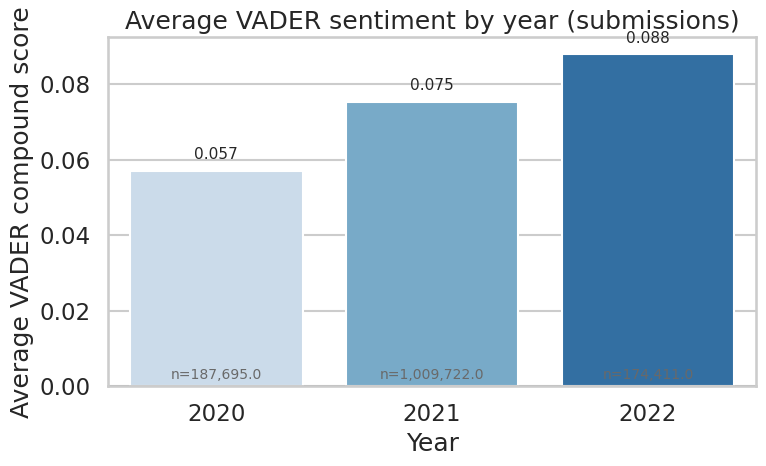

,year,avg_sentiment,n
0,2020,0.057156,187695
1,2021,0.075450,1009722
2,2022,0.088072,174411


In [21]:
# Prettier yearly sentiment chart (2020–2022)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

yearly = (
    submissions_sent
    .withColumn("year", F.year("date"))
    .filter(F.col("year").isin([2020, 2021, 2022]))
    .groupBy("year")
    .agg(
        F.avg("sentiment_vader").alias("avg_sentiment"),
        F.count("*").alias("n")
    )
    .orderBy("year")
    .toPandas()
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=yearly,
    x="year",
    y="avg_sentiment",
    palette="Blues"
)

# Add value labels + sample size
for i, row in yearly.iterrows():
    ax.text(i, row["avg_sentiment"] + 0.003, f"{row['avg_sentiment']:.3f}", ha="center", fontsize=11)
    ax.text(i, 0.002, f"n={row['n']:,}", ha="center", fontsize=10, color="dimgray")

# Zero line for neutral sentiment
ax.axhline(0, color="black", linewidth=1)

ax.set_title("Average VADER sentiment by year (submissions)")
ax.set_ylabel("Average VADER compound score")
ax.set_xlabel("Year")

plt.tight_layout()
plt.show()

yearly

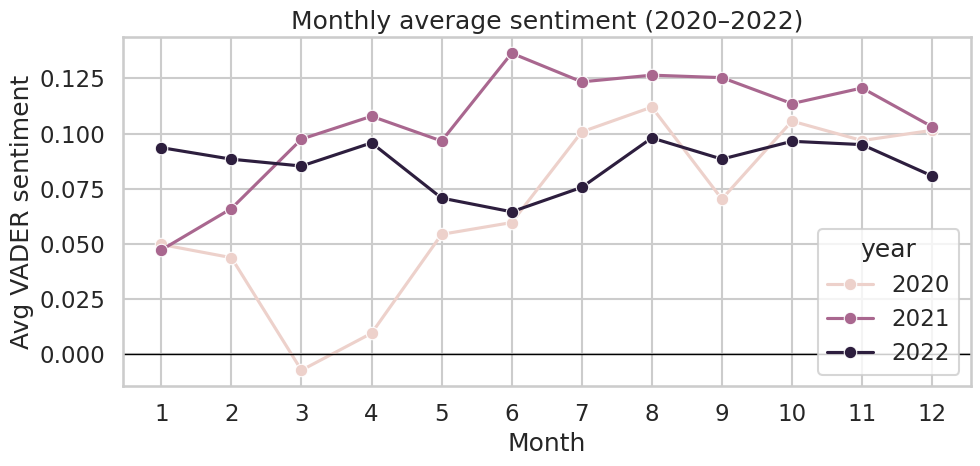

In [22]:
sns.set_theme(style="whitegrid", context="talk")

monthly = (
    submissions_sent
    .withColumn("year", F.year("date"))
    .withColumn("month", F.month("date"))
    .filter(F.col("year").isin([2020, 2021, 2022]))
    .groupBy("year", "month")
    .agg(F.avg("sentiment_vader").alias("avg_sentiment"))
    .orderBy("year", "month")
    .toPandas()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x="month", y="avg_sentiment", hue="year", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Monthly average sentiment (2020–2022)")
plt.xlabel("Month")
plt.ylabel("Avg VADER sentiment")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

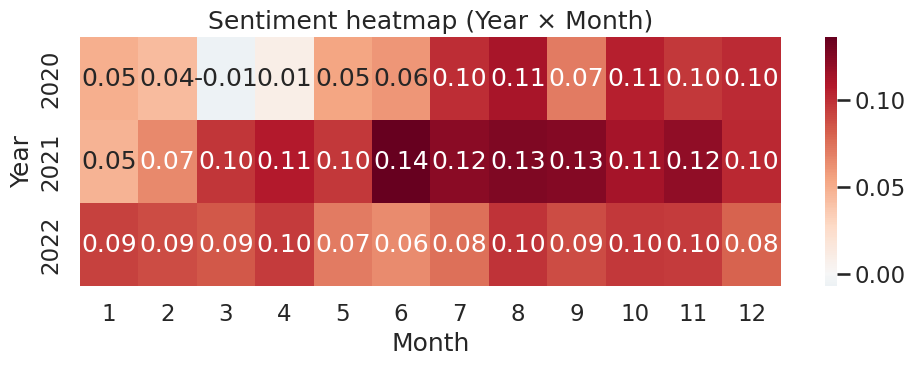

In [23]:
heat = monthly.pivot(index="year", columns="month", values="avg_sentiment")

plt.figure(figsize=(10,4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Sentiment heatmap (Year × Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

/scratch/local/jobs/48788194/ipykernel_2400656/155393011.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sample, x="year", y="sentiment_vader", inner="quartile", palette="Blues")


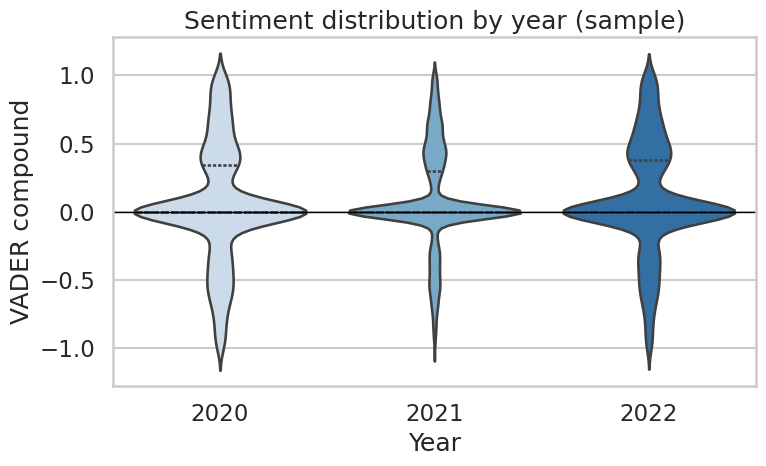

In [24]:
sample = (
    submissions_sent
    .withColumn("year", F.year("date"))
    .filter(F.col("year").isin([2020, 2021, 2022]))
    .sample(fraction=0.02, seed=42)
    .select("year", "sentiment_vader")
    .toPandas()
)

plt.figure(figsize=(8,5))
sns.violinplot(data=sample, x="year", y="sentiment_vader", inner="quartile", palette="Blues")
plt.axhline(0, color="black", linewidth=1)
plt.title("Sentiment distribution by year (sample)")
plt.xlabel("Year")
plt.ylabel("VADER compound")
plt.tight_layout()
plt.show()

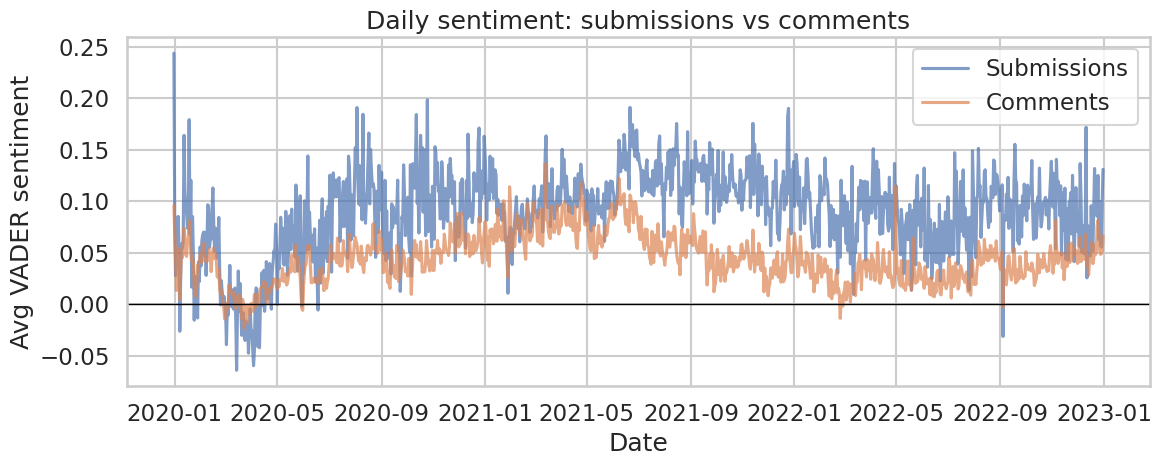

In [25]:
subs_daily = submissions_sent.groupBy("date").agg(F.avg("sentiment_vader").alias("subs_sent"))
coms_daily = comments_sent.groupBy("date").agg(F.avg("sentiment_vader").alias("coms_sent"))

daily = (subs_daily.join(coms_daily, on="date", how="inner")
         .orderBy("date")
         .toPandas())

plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["subs_sent"], label="Submissions", alpha=0.7)
plt.plot(daily["date"], daily["coms_sent"], label="Comments", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily sentiment: submissions vs comments")
plt.xlabel("Date")
plt.ylabel("Avg VADER sentiment")
plt.legend()
plt.tight_layout()
plt.show()

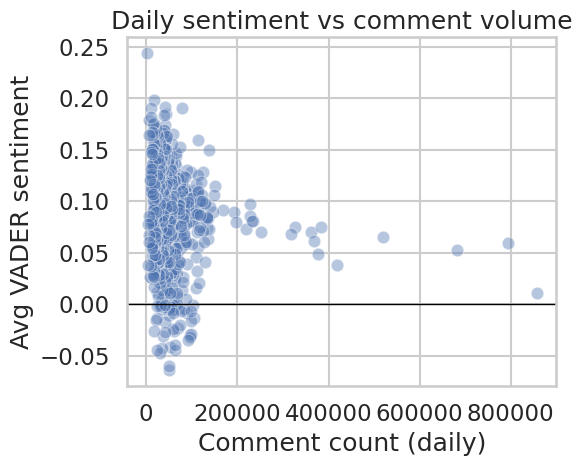

In [26]:
daily_sent = submissions_sent.groupBy("date").agg(F.avg("sentiment_vader").alias("avg_sent"))
daily_comments = comments_sent.groupBy("date").agg(F.count("*").alias("comment_count"))

joined = (daily_sent.join(daily_comments, on="date", how="inner")
          .toPandas())

plt.figure(figsize=(6,5))
sns.scatterplot(data=joined, x="comment_count", y="avg_sent", alpha=0.4)
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily sentiment vs comment volume")
plt.xlabel("Comment count (daily)")
plt.ylabel("Avg VADER sentiment")
plt.tight_layout()
plt.show()

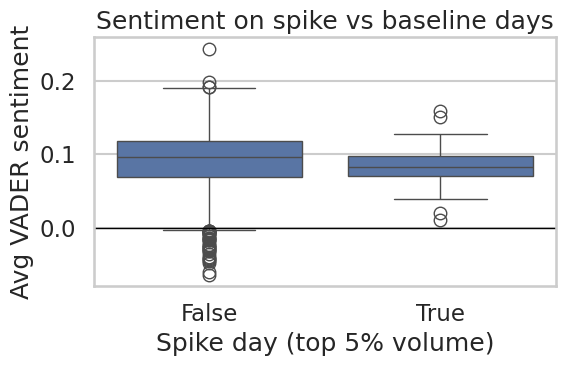

In [27]:
# Define spikes as top 5% comment volume days
spike_threshold = joined["comment_count"].quantile(0.95)
joined["is_spike"] = joined["comment_count"] >= spike_threshold

plt.figure(figsize=(6,4))
sns.boxplot(data=joined, x="is_spike", y="avg_sent")
plt.axhline(0, color="black", linewidth=1)
plt.title("Sentiment on spike vs baseline days")
plt.xlabel("Spike day (top 5% volume)")
plt.ylabel("Avg VADER sentiment")
plt.tight_layout()
plt.show()

/scratch/local/jobs/48788194/ipykernel_2400656/70636767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pos, x="avg_sent", y="date", palette="Greens_r")


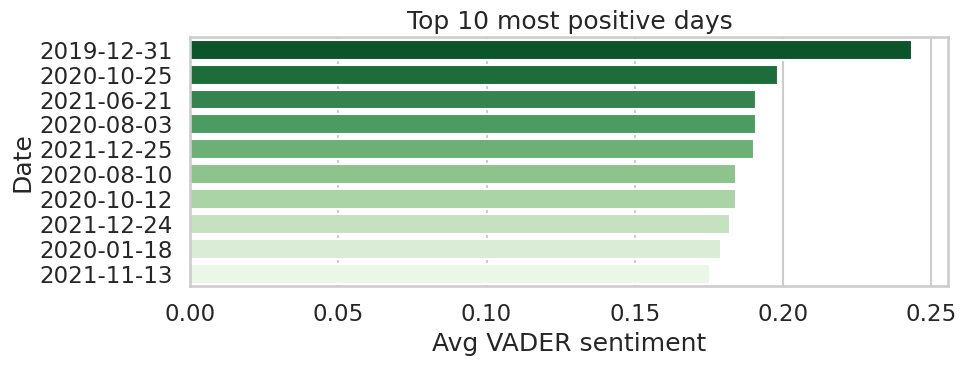

/scratch/local/jobs/48788194/ipykernel_2400656/70636767.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neg, x="avg_sent", y="date", palette="Reds")


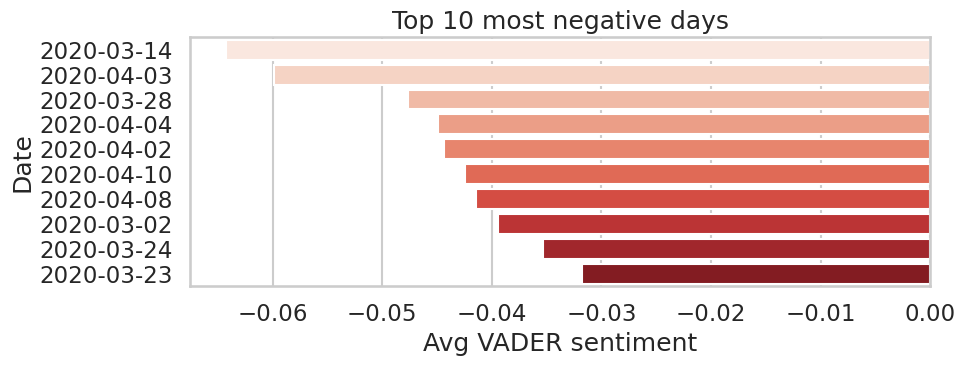

In [28]:
top_pos = joined.sort_values("avg_sent", ascending=False).head(10)
top_neg = joined.sort_values("avg_sent", ascending=True).head(10)

plt.figure(figsize=(10,4))
sns.barplot(data=top_pos, x="avg_sent", y="date", palette="Greens_r")
plt.title("Top 10 most positive days")
plt.xlabel("Avg VADER sentiment")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=top_neg, x="avg_sent", y="date", palette="Reds")
plt.title("Top 10 most negative days")
plt.xlabel("Avg VADER sentiment")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

In [29]:
# Define windows
pre_start, pre_end = "2020-11-01", "2021-01-15"
gme_start, gme_end = "2021-01-16", "2021-02-15"
post_start, post_end = "2021-02-16", "2021-04-30"

def window_summary(df, label):
    out = (df.filter(F.col("date").between(label[0], label[1]))
             .agg(
                 F.count("*").alias("n"),
                 F.avg("sentiment_vader").alias("avg_sent"),
                 F.countDistinct("author").alias("unique_authors")
             )
             .withColumn("window", F.lit(f"{label[0]} to {label[1]}")))
    return out

summary = (
    window_summary(submissions_sent, (pre_start, pre_end))
    .union(window_summary(submissions_sent, (gme_start, gme_end)))
    .union(window_summary(submissions_sent, (post_start, post_end)))
)

summary.show(truncate=False)

[Stage 445:==============>(24 + 1) / 25][Stage 446:===============(25 + 0) / 25]

+------+-------------------+--------------+------------------------+
|n     |avg_sent           |unique_authors|window                  |
+------+-------------------+--------------+------------------------+
|49285 |0.10358828040986137|27989         |2020-11-01 to 2021-01-15|
|597400|0.05148673384666763|375529        |2021-01-16 to 2021-02-15|
|179030|0.09523329777132215|113470        |2021-02-16 to 2021-04-30|
+------+-------------------+--------------+------------------------+



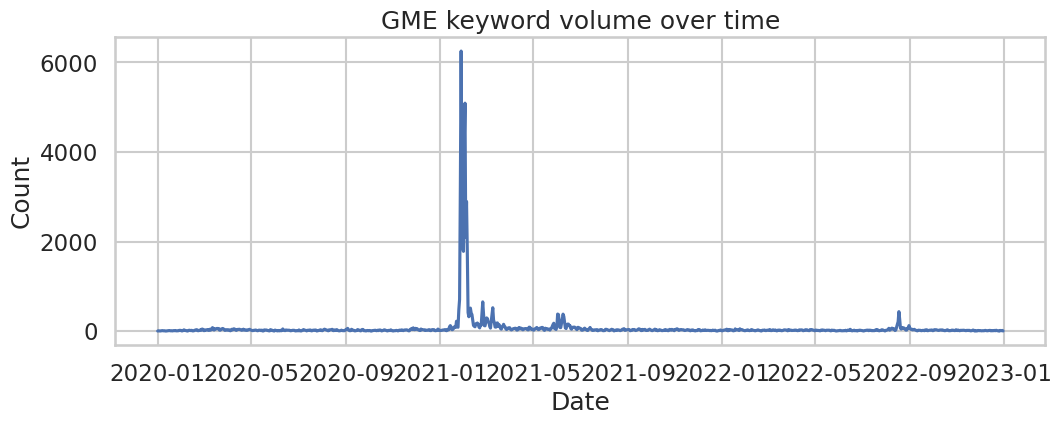

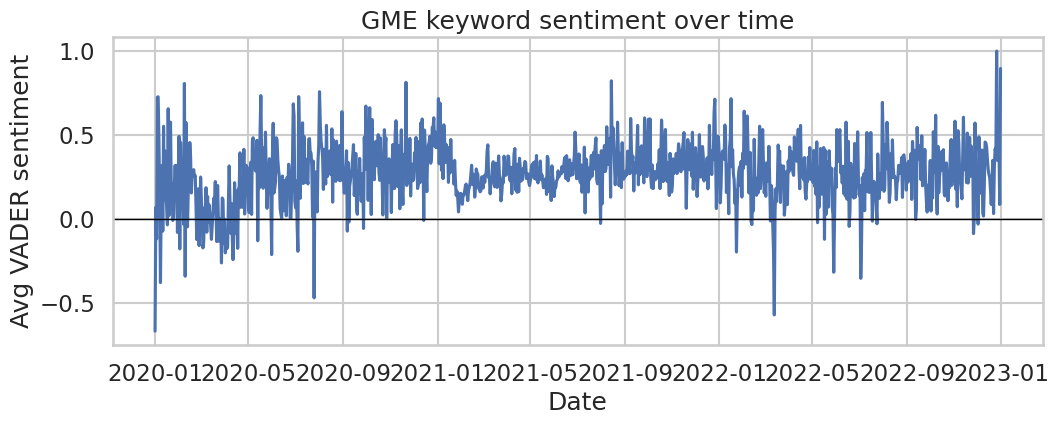

In [30]:
gme_terms = r"(gme|gamestop|amc|short\s*squeeze|diamond\s*hands|paper\s*hands|hold|hodl)"

gme_posts = submissions_sent.filter(F.col("text").rlike(gme_terms))

gme_daily = (
    gme_posts.groupBy("date")
    .agg(
        F.count("*").alias("gme_posts"),
        F.avg("sentiment_vader").alias("avg_sent")
    )
    .orderBy("date")
    .toPandas()
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12,4))
sns.lineplot(data=gme_daily, x="date", y="gme_posts")
plt.title("GME keyword volume over time")
plt.ylabel("Count")
plt.xlabel("Date")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(data=gme_daily, x="date", y="avg_sent")
plt.axhline(0, color="black", linewidth=1)
plt.title("GME keyword sentiment over time")
plt.ylabel("Avg VADER sentiment")
plt.xlabel("Date")
plt.show()

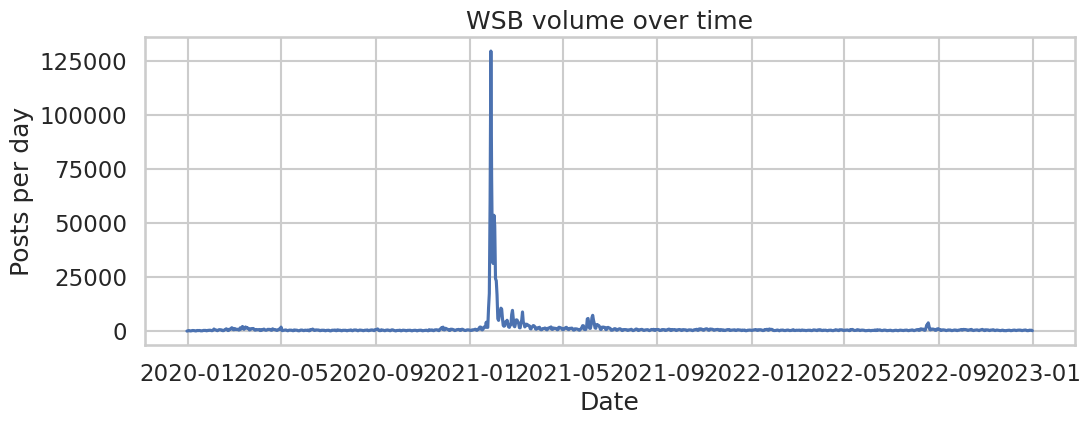

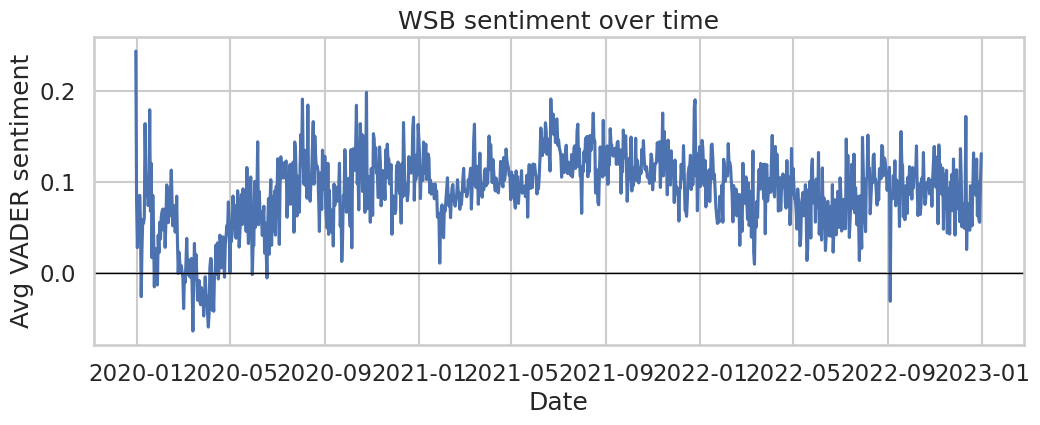

In [31]:
wsb = submissions_sent.filter(F.lower(F.col("subreddit")) == "wallstreetbets")

wsb_daily = (
    wsb.groupBy("date")
    .agg(
        F.count("*").alias("wsb_posts"),
        F.avg("sentiment_vader").alias("avg_sent")
    )
    .orderBy("date")
    .toPandas()
)

plt.figure(figsize=(12,4))
sns.lineplot(data=wsb_daily, x="date", y="wsb_posts")
plt.title("WSB volume over time")
plt.ylabel("Posts per day")
plt.xlabel("Date")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(data=wsb_daily, x="date", y="avg_sent")
plt.axhline(0, color="black", linewidth=1)
plt.title("WSB sentiment over time")
plt.ylabel("Avg VADER sentiment")
plt.xlabel("Date")
plt.show()

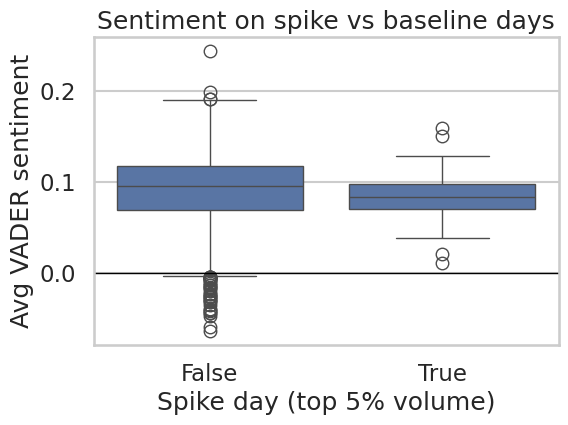

In [32]:
daily_comments = comments_sent.groupBy("date").agg(F.count("*").alias("comment_count")).toPandas()
daily_sent = submissions_sent.groupBy("date").agg(F.avg("sentiment_vader").alias("avg_sent")).toPandas()

joined = daily_sent.merge(daily_comments, on="date")
spike_threshold = joined["comment_count"].quantile(0.95)
joined["is_spike"] = joined["comment_count"] >= spike_threshold

plt.figure(figsize=(6,4))
sns.boxplot(data=joined, x="is_spike", y="avg_sent")
plt.axhline(0, color="black", linewidth=1)
plt.title("Sentiment on spike vs baseline days")
plt.xlabel("Spike day (top 5% volume)")
plt.ylabel("Avg VADER sentiment")
plt.show()

In [33]:
top_pos = joined.sort_values("avg_sent", ascending=False).head(10)
top_neg = joined.sort_values("avg_sent", ascending=True).head(10)

top_pos, top_neg

(            date  avg_sent  comment_count  is_spike
 1059  2019-12-31  0.243754           1353     False
 1075  2020-10-25  0.198371          16302     False
 133   2021-06-21  0.191057          40016     False
 538   2020-08-03  0.190929          78215     False
 1033  2021-12-25  0.190163           9920     False
 782   2020-08-10  0.184385          44233     False
 353   2020-10-12  0.184117          39396     False
 1042  2021-12-24  0.182196           9728     False
 15    2020-01-18  0.179152           6222     False
 644   2021-11-13  0.175520          17238     False,
            date  avg_sent  comment_count  is_spike
 216  2020-03-14 -0.064276          50199     False
 277  2020-04-03 -0.059867          49729     False
 131  2020-03-28 -0.047667          30919     False
 708  2020-04-04 -0.044924          23424     False
 621  2020-04-02 -0.044343          63722     False
 117  2020-04-10 -0.042466          33847     False
 383  2020-04-08 -0.041411          51257     False


## Summary
This notebook builds a sentiment pipeline with VADER and then layers multiple views to understand how sentiment behaves over time, across aggregation levels, and across content types. The yearly chart shows a small but consistent upward drift in average sentiment from 2020 to 2022, while the monthly trend and heatmap reveal that changes are not uniform across the calendar; instead, short windows carry outsized shifts that pull the annual average up or down. The violin distribution adds critical context: the mean changes are modest because the distribution is wide and centered near zero, so shifts in the tail or variance matter as much as shifts in the mean. In other words, the overall tone is only slightly positive, but the dispersion indicates frequent swings between negative and positive content.

The submissions-vs-comments time series aligns the two channels and shows they move together, but not perfectly, implying that the emotional tone of posts and replies can diverge on specific days. The spike-vs-baseline comparison reinforces that story: high-volume days are not simply "more positive" or "more negative" on average; instead, they are more volatile and attention-driven. The top positive/negative day lists provide concrete anchors for interpretation, while the keyword and subreddit-focused plots demonstrate that topic-specific surges (like GME/WSB) concentrate attention into narrow time windows that dominate the broader aggregate patterns.

## Narrative - GameStop Era Focus
The GameStop era emerges clearly as a concentrated attention shock rather than a slow-moving sentiment drift. The GME keyword volume curve shows a dramatic and isolated spike in late January 2021, mirrored by a sharp surge in WSB posting volume. This timing lines up with the well-known short-squeeze period and indicates that the event is defined first by scale and coordination of participation. Sentiment during that window remains slightly positive on average, but the critical signal is the surge in volume and the concentration of conversation around a narrow set of tickers and action words (e.g., GME, hold, short squeeze).

Comparing pre-, peak-, and post-windows shows that participation and unique authors expand sharply during the GameStop window and then relax afterward, consistent with a burst of collective attention. The spike-vs-baseline boxplot reinforces that spike days are not uniformly positive or negative; instead, they are more emotionally charged and heterogeneous. Taken together, these visuals support a narrative in which the GameStop episode is characterized by a rapid, coordinated surge in attention and participation, with sentiment shifting but not uniformly so, reflecting a highly polarized and fast-moving discourse rather than a single dominant mood.